# Desafío 4

Alumno: Rodrigo Mesa Marchi (a2016)

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## LSTM Traductor


In [3]:
import re
import os
import pandas as pd
import torch.nn.functional as F
import spacy
import torch
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from spacy.symbols import ORTH
import json 
import numpy as np
import pickle
import torch.nn as nn
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

In [4]:
# Descargar la carpeta de dataset

if os.access('spa-eng', os.F_OK) is False:
    if os.access('spa-eng.zip', os.F_OK) is False:
        !curl -L -o 'spa-eng.zip' 'http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip'
    !unzip -q spa-eng.zip 
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


## Generación de dataset y embeddings

Para este ejercicio, no se limitó el tamaño del dataset de entrenamiento, se procedió entrenando con la totalidad del mismo.

In [5]:
# Tokens especiales y parámetros
MAX_VOCAB_SIZE = 8000

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

Utilizamos pandas para procesar dataframe de forma mas sencilla, obtenemos secuencias de input y output

In [6]:
df = pd.read_csv("./spa-eng/spa.txt", sep='\t', names=["input", "output"])
df["output_sentence"] = df["output"] + f' {EOS_TOKEN}'
df["output_sentence_input"] = f'{SOS_TOKEN} ' + df["output"]
#df = df.sample(n = MAX_NUM_SENTENCES)
input_sentences = df["input"].to_list()
output_sequence = df["output_sentence"].to_list()
output_sequence_input = df["output_sentence_input"].to_list()

Para tokenizar, utilizamos la librería spacy, la cual simplifica el proceso. Debido a que utilizaremos la totalidad del las frases, no utilizamos el truncamiento de las frases, sino que el padding se realizará simplemente para el tamaño máximo de frases del dataset de input y output.

In [7]:
# Cargar modelos spaCy
spacy_eng = spacy.load("en_core_web_sm")
spacy_esp = spacy.load("es_core_news_sm")

# Definimos y agregamos tokens especiales
special_tokens = [SOS_TOKEN, EOS_TOKEN]

for token in special_tokens:
    spacy_esp.tokenizer.add_special_case(token, [{ORTH: token}])


def tokenize_spacy_pipe(sentences, nlp):
    return [[token.text.lower() for token in doc] for doc in nlp.pipe(sentences, batch_size=64)]


input_tokenized = tokenize_spacy_pipe(input_sentences, spacy_eng)
output_tokenized_input = tokenize_spacy_pipe(output_sequence_input, spacy_esp)  # con <sos>
output_tokenized_target = tokenize_spacy_pipe(output_sequence, spacy_esp)       # con <eos>


# --- 2. Construir vocabularios ---
def build_vocab(tokenized_sentences, max_vocab_size):
    PAD_TOKEN = "<pad>"
    UNK_TOKEN = "<unk>"
    SOS_TOKEN = "<sos>"
    EOS_TOKEN = "<eos>"
    
    # Contar tokens
    counter = Counter(token for sentence in tokenized_sentences for token in sentence)
    most_common = counter.most_common(max_vocab_size - 4)  # reservar 4 para los tokens especiales
    
    # Diccionario palabra → índice
    word2idx = {
        PAD_TOKEN: 0,
        UNK_TOKEN: 1,
        SOS_TOKEN: 2,
        EOS_TOKEN: 3
    }
    
    # Añadir palabras del vocabulario empezando desde el índice 4
    for i, (word, _) in enumerate(most_common, start=4):
        if word not in word2idx:  # evitar sobrescribir los especiales
            word2idx[word] = i
    
    # Diccionario inverso
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    return word2idx, idx2word

# Para el vocabulario de input (inglés)
word2idx_input, idx2word_input = build_vocab(input_tokenized, MAX_VOCAB_SIZE)
# Para el vocabulario de output (español), junto input y target para vocab completo
word2idx_output, idx2word_output = build_vocab(output_tokenized_input + output_tokenized_target, MAX_VOCAB_SIZE)

# --- 3. Pasar tokens a ids ---
def tokens_to_ids(tokenized_sentences, word2idx):
    return [
        torch.tensor([word2idx.get(token, word2idx[UNK_TOKEN]) for token in sentence], dtype=torch.long)
        for sentence in tokenized_sentences
    ]

encoder_sequences = tokens_to_ids(input_tokenized, word2idx_input)
decoder_input_sequences = tokens_to_ids(output_tokenized_input, word2idx_output)
decoder_target_sequences = tokens_to_ids(output_tokenized_target, word2idx_output)

# --- 4. Padding con PyTorch ---
encoder_padded = pad_sequence(encoder_sequences, batch_first=True, padding_value=word2idx_input[PAD_TOKEN], padding_side='left')
decoder_input_padded = pad_sequence(decoder_input_sequences, batch_first=True, padding_value=word2idx_output[PAD_TOKEN],padding_side='right')
decoder_target_padded = pad_sequence(decoder_target_sequences, batch_first=True, padding_value=word2idx_output[PAD_TOKEN],padding_side='right')

# --- 5. Mostrar resultados ---
print("encoder_padded shape:", encoder_padded.shape)
print("decoder_input_padded shape:", decoder_input_padded.shape)
print("decoder_target_padded shape:", decoder_target_padded.shape)

# Ejemplo
i = 0
print("\nEjemplo frase input original:", input_sentences[i])
print("Tokenizada:", input_tokenized[i])
print("Indexada:", encoder_sequences[i])
print("Padded:", encoder_padded[i])

print("\nEjemplo frase output_input (con <sos>):", output_sequence_input[i])
print("Tokenizada:", output_tokenized_input[i])
print("Indexada:", decoder_input_sequences[i])
print("Padded:", decoder_input_padded[i])

print("\nEjemplo frase output_target (con <eos>):", output_sequence[i])
print("Tokenizada:", output_tokenized_target[i])
print("Indexada:", decoder_target_sequences[i])
print("Padded:", decoder_target_padded[i])


# Guardar tensores PyTorch
torch.save(encoder_padded, "encoder_padded.pt")
torch.save(decoder_input_padded, "decoder_input_padded.pt")
torch.save(decoder_target_padded, "decoder_target_padded.pt")

# Guardar vocabularios como JSON
with open("word2idx_input.json", "w", encoding="utf-8") as f:
    json.dump(word2idx_input, f, ensure_ascii=False)

with open("idx2word_input.json", "w", encoding="utf-8") as f:
    json.dump(idx2word_input, f, ensure_ascii=False)

with open("word2idx_output.json", "w", encoding="utf-8") as f:
    json.dump(word2idx_output, f, ensure_ascii=False)

with open("idx2word_output.json", "w", encoding="utf-8") as f:
    json.dump(idx2word_output, f, ensure_ascii=False)

encoder_padded shape: torch.Size([118964, 49])
decoder_input_padded shape: torch.Size([118964, 52])
decoder_target_padded shape: torch.Size([118964, 52])

Ejemplo frase input original: Go.
Tokenizada: ['go', '.']
Indexada: tensor([50,  4])
Padded: tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 50,  4])

Ejemplo frase output_input (con <sos>): <sos> Ve.
Tokenizada: ['<sos>', 've', '.']
Indexada: tensor([  2, 376,   4])
Padded: tensor([  2, 376,   4,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0])

Ejemplo frase output_target (con <eos>): Ve. <eos>
Tokenizada: ['ve', '.', '<eos>']
Indexada: tensor([376,   4,

Realizamos una modificación en la estructura interna de la red, en donde simplemente el output de la capa fully connected se lo compara con el token real. Con ello, evitamos definir la matriz de one hot para toda las frases, redujendo enormemente el uso de memoria. Esto nos permitió entrenar con todo el dataset completo.

In [8]:
# Cargar tensores PyTorch
encoder_padded = torch.load("encoder_padded.pt")
decoder_input_padded = torch.load("decoder_input_padded.pt")
decoder_target_padded = torch.load("decoder_target_padded.pt")

# Cargar vocabularios desde archivos JSON
with open("word2idx_input.json", "r", encoding="utf-8") as f:
    word2idx_input = json.load(f)

with open("idx2word_input.json", "r", encoding="utf-8") as f:
    idx2word_input = json.load(f)

with open("word2idx_output.json", "r", encoding="utf-8") as f:
    word2idx_output = json.load(f)

with open("idx2word_output.json", "r", encoding="utf-8") as f:
    idx2word_output = json.load(f)

In [9]:
len(word2idx_output)

7998

In [10]:
MAX_INPUT_LEN= encoder_padded.shape[1]
MAX_OUTPUT_LEN= decoder_target_padded.shape[1]

In [11]:
decoder_target_padded.max()

tensor(7999)

In [12]:
num_classes = min(len(word2idx_output)+2, MAX_VOCAB_SIZE)

Para construir la capa de embeddings de input, descargamos los pesos desde Goodgle Drive.

In [13]:
# Descargar los embeddings desde un google drive (es la forma más rápida)
# NOTA: No hay garantía de que estos links perduren, en caso de que no estén
# disponibles descargar de la página oficial como se explica en el siguiente bloque de código
import os
import gdown
if os.access('gloveembedding.pkl', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&export=download'
    output = 'gloveembedding.pkl'
    gdown.download(url, output, quiet=False)
else:
    print("Los embeddings gloveembedding.pkl ya están descargados")

Los embeddings gloveembedding.pkl ya están descargados


In [19]:
PKL_PATH = 'gloveembedding.pkl'

# === Cargar los embeddings desde el .pkl ===
with open(PKL_PATH, 'rb') as f:
    embeddings = pickle.load(f)  # np.recarray

embed_dim = embeddings['embedding'].shape[1]
word_to_vec = {word: vec for word, vec in zip(embeddings['word'], embeddings['embedding'])}

# === Crear la embedding matrix para el vocabulario ===
print('Preparing embedding matrix...')

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_input))
embedding_matrix = np.zeros((nb_words, embed_dim), dtype=np.float32)
words_not_found = []

for word, idx in word2idx_input.items():
    if idx >= nb_words:
        continue
    vec = word_to_vec.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
    else:
        words_not_found.append(word)

# === Información útil ===
num_null = np.sum(np.sum(embedding_matrix**2, axis=1) == 0)
print(f'Number of null word embeddings: {num_null}')
print(f'Words not found: {len(words_not_found)}')

# === Convertir a tensor PyTorch para usar en nn.Embedding ===
embedding_tensor = torch.tensor(embedding_matrix)
embedding_layer = torch.nn.Embedding.from_pretrained(embedding_tensor, freeze=True)

Preparing embedding matrix...
Number of null word embeddings: 127
Words not found: 127


## Definición de la red

Siguiendo los lineamientos de las consignas, adaptamos la red desarrollada en Keras a una desarrollada en Pytorch. A su vez, esta red la definimos utilizando pytorch lighting: un framework que nos permite simplificar el entrenamiento al hacer uso de distintas clases auxiliares. Simplemente mediante la definición de las clases para el modelo, y los datasets, haremos uso de los módulos para entrenamiento.

In [36]:
import torch
import torch.nn as nn

class TranslateModel(L.LightningModule):
    def __init__(self, 
                 embedding_matrix, # Matriz de embedding para encoder (preentrenada)
                 num_words_output, # Cantidad de palabras a la salida
                 embed_dim,        # Cantidad de palabras a la entrada
                 n_units,          # Cantidad de neuronas en la capa oculta de LSTMs
                 max_input_len,     
                 max_out_len,
                 lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        self.encoder_embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=True
        )

        self.encoder_lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=n_units,
            batch_first=True
        )

        self.decoder_embedding = nn.Embedding(
            num_embeddings=num_words_output,
            embedding_dim=n_units
        )

        self.decoder_lstm = nn.LSTM(
            input_size=n_units,
            hidden_size=n_units,
            batch_first=True
        )

        self.fc = nn.Linear(n_units, num_words_output)
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=0)  # 0 = padding
        self.lr = lr
    def forward(self, encoder_input_ids, decoder_input_ids):
        # === Encoder ===
        encoder_embedded = self.encoder_embedding(encoder_input_ids)  # (batch, seq_len, embed_dim)
        encoder_outputs, (h, c) = self.encoder_lstm(encoder_embedded)

        # === Decoder ===
        decoder_embedded = self.decoder_embedding(decoder_input_ids)  # (batch, seq_len, n_units)
        decoder_outputs, _ = self.decoder_lstm(decoder_embedded, (h, c))  # initial_state = encoder's final states

        # === Output ===
        output = self.fc(decoder_outputs)  # (batch, seq_len, num_words_output)
        return output



    def training_step(self, batch, batch_idx):
        encoder_input, decoder_input, decoder_target = batch
        logits = self(encoder_input, decoder_input)
        loss = self.loss_fn(logits.view(-1, logits.size(-1)), decoder_target.view(-1))
        # esto loggea al trainer automáticamente
        self.log_dict(
            {"train_loss": loss},
            on_step=False, on_epoch=True, prog_bar=True, logger=True
        )
        return loss

    def validation_step(self, batch, batch_idx):
        encoder_input, decoder_input, decoder_target = batch
        logits = self(encoder_input, decoder_input)
        loss = self.loss_fn(logits.view(-1, logits.size(-1)), decoder_target.view(-1))
        self.log_dict(
            {"val_loss": loss,},
            on_step=False, on_epoch=True, prog_bar=True, logger=True
        )


    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

    def predict_step(self, batch, batch_idx, **kwargs):
        encoder_input, _, _ = batch
        return self.generate(encoder_input)

    import torch

    def generate(
        self,
        encoder_input_ids,
        sos_token_id=2,
        eos_token_id=3,
        max_len=None,
        pad_token_id=0,
        return_trimmed=True,   # recorta cada secuencia al primer <eos> (incluido)
    ):
        if max_len is None:
            max_len = self.hparams.max_out_len

        batch_size = encoder_input_ids.size(0)
        device = encoder_input_ids.device

        # Encode
        encoder_embedded = self.encoder_embedding(encoder_input_ids)
        _, (h, c) = self.encoder_lstm(encoder_embedded)

        # Primer input del decoder: <sos>
        decoder_input = torch.full(
            (batch_size, 1), sos_token_id, dtype=torch.long, device=device
        )

        outputs = []
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        for _ in range(max_len):
            # Paso del decoder
            decoder_embedded = self.decoder_embedding(decoder_input)  # (B,1,E)
            decoder_output, (h, c) = self.decoder_lstm(decoder_embedded, (h, c))
            logits = self.fc(decoder_output[:, -1, :])                # (B,V)

            # Greedy
            next_tokens = torch.argmax(logits, dim=-1)                # (B,)

            # Para ejemplos ya terminados, mantené el token de entrada en <eos>
            # (no cambiamos su estado de "finished")
            next_tokens = torch.where(
                finished, torch.tensor(eos_token_id, device=device), next_tokens
            )

            # Guardar salida de este paso.
            # Para no “ensuciar” con <eos> repetidos, escribimos PAD en posiciones ya terminadas
            token_to_write = torch.where(
                finished, torch.tensor(pad_token_id, device=device), next_tokens
            )
            outputs.append(token_to_write.unsqueeze(1))               # (B,1)

            # Actualizar mask de terminación
            finished = finished | (next_tokens == eos_token_id)

            # Siguiente entrada del decoder
            decoder_input = next_tokens.unsqueeze(1)

            # Corta temprano si todos terminaron
            if finished.all():
                break

        # (B, T_gen)
        outputs = torch.cat(outputs, dim=1) if outputs else torch.empty(
            batch_size, 0, dtype=torch.long, device=device
        )

        if return_trimmed:
            # Recorta cada fila hasta el primer <eos> (incluyéndolo).
            trimmed = []
            for i in range(batch_size):
                row = torch.cat([outputs[i]])  # 1D
                eos_pos = (row == eos_token_id).nonzero(as_tuple=False)
                end = eos_pos[0].item() + 1 if eos_pos.numel() > 0 else row.size(0)
                trimmed.append(row[:end])
            return trimmed  # lista de tensores 1D de longitudes variables
        else:
            # Si querés forma rectangular, devolvé padded (ya tiene PAD donde terminó).
            # Si el loop cortó antes de max_len, completamos al tope con PAD.
            if outputs.size(1) < max_len:
                pad_len = max_len - outputs.size(1)
                pad = torch.full(
                    (batch_size, pad_len), pad_token_id, dtype=torch.long, device=device
                )
                outputs = torch.cat([outputs, pad], dim=1)
            return outputs





Definimos el objeto dataset dataset

In [37]:
from torch.utils.data import Dataset

class TranslationDataset(Dataset):
    def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
        self.encoder_inputs = encoder_inputs  # (num_samples, max_input_len)
        self.decoder_inputs = decoder_inputs  # (num_samples, max_output_len)
        self.decoder_targets = decoder_targets

    def __len__(self):
        return len(self.encoder_inputs)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encoder_inputs[idx], dtype=torch.long),
            torch.tensor(self.decoder_inputs[idx], dtype=torch.long),
            torch.tensor(self.decoder_targets[idx], dtype=torch.long)
        )

In [38]:
num_words_output = min(MAX_VOCAB_SIZE+3, len(word2idx_output)+3)  # +3 por caracteres especiales

Con esto, realizamos entrenamiento del modelo, usando un 20% para validación. Configuramos además algunos callbacks de lighting para early stopping y logging

In [40]:
from torch.utils.data import DataLoader, random_split
from lightning.pytorch.loggers import CSVLogger

csv_logger = CSVLogger(save_dir="logs", name="seq2seq")  # logs/seq2seq/version_0/metrics.csv
# Preparar datos
dataset = TranslationDataset(encoder_padded, decoder_input_padded, decoder_target_padded)


early_stop = EarlyStopping(
    monitor="val_loss",   # must match your logged key
    mode="min",           # "min" because lower val_loss is better
    patience=3,           # epochs with no improvement before stopping
    min_delta=0.0,        # minimum change to qualify as an improvement
)

ckpt = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,         # keep the best checkpoint
    filename="best-{epoch:02d}-{val_loss:.4f}",
)


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)

# Crear modelo
model = TranslateModel(
    embedding_matrix=torch.tensor(embedding_matrix),
    num_words_output=num_words_output,
    embed_dim=embed_dim,
    n_units=250,
    max_input_len=MAX_INPUT_LEN,
    max_out_len=MAX_OUTPUT_LEN,
    lr=1e-3
)

# Entrenar
trainer = L.Trainer(
    max_epochs=30,
    accelerator="auto",
    devices="auto",
    logger=csv_logger,
    log_every_n_steps=10,
    callbacks=[early_stop, ckpt],
)
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | encoder_embedding | Embedding        | 400 K  | train
1 | encoder_lstm      | LSTM             | 302 K  | train
2 | decoder_embedding | Embedding        | 2.0 M  | train
3 | decoder_lstm      | LSTM             | 502 K  | train
4 | fc                | Linear           | 2.0 M  | train
5 | loss_fn           | CrossEntropyLoss | 0      | train
---------------------------------------------------------------
4.8 M     Trainable params
400 K     Non-trainable params
5.2 M     Total params
20.850    Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


/tmp/ipykernel_19525/1396719371.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.encoder_inputs[idx], dtype=torch.long),
/tmp/ipykernel_19525/1396719371.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.decoder_inputs[idx], dtype=torch.long),
/tmp/ipykernel_19525/1396719371.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.decoder_targets[idx], dtype=torch.long)


Epoch 14: 100%|██████████| 744/744 [00:26<00:00, 28.01it/s, v_num=12, val_loss=1.790, train_loss=0.786]


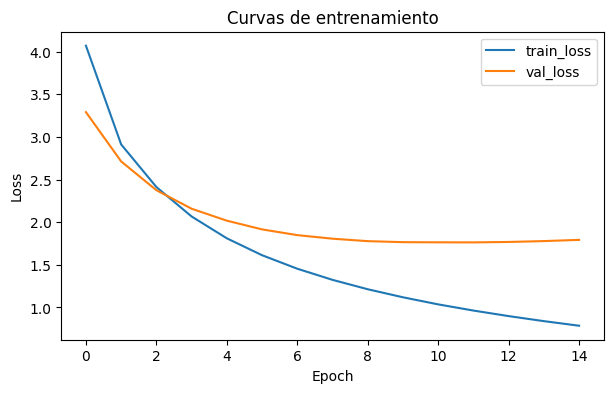

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def load_csv_metrics(log_dir="logs/seq2seq"):
    versions = sorted(Path(log_dir).glob("version_*"), key=lambda p: int(p.name.split("_")[-1]))
    assert versions, f"No hay versiones en {log_dir}"
    df = pd.read_csv(versions[-1] / "metrics.csv")
    return df

df = load_csv_metrics()

# Curvas por época (Lightning guarda varias filas por step → usamos el último por epoch)
plt.figure(figsize=(7,4))
df.groupby("epoch")["train_loss"].last().plot(label="train_loss")
df.groupby("epoch")["val_loss"].last().plot(label="val_loss")
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Curvas de entrenamiento"); plt.show()

Al analizar los resultados, encontramos como hubo un entrenamiento hasta 14 epochs. Vemos a su vez como tuvimos cierto grado de overfitting, por lo que el modelo se detuvo antes de las 30 epochs totales.

## Pruebas de funcionamiento

Ahora realizaremos las pruebas finales de los resultados de entrenamiento. Para ello, seguiremos los siguientes pasos:
1. Tomamos N secuencias aleatorias del dataset. Esto lo realizamos para poder contar con palabras incluidas en el vocabulario.
1. A estas secuencias las convertimos de indice a palabra para despues poder compararlas con la salida
1. Hacemos una generación de la red, realizando la traduccion en una pasada de la red. Cada una de la secuencias finalizará cuando la salida arroje un EOS.
1. El resultado de la red lo convertimos de indice a palabras


In [46]:
def output_to_text(res, idx2word_output):
    lista_traduccion = []
    for sentence in res:
        frase = []
        for word in sentence:
            frase.append(idx2word_output[str(int(word))])
        lista_traduccion.append(frase)
    return lista_traduccion

In [55]:
N = encoder_padded.size(0)
indices = torch.randint(0, N, (5,))
input_encoder_sequences = encoder_padded[indices]


test_input_padded = pad_sequence(input_encoder_sequences, batch_first=True, padding_value=word2idx_input[PAD_TOKEN], padding_side='left')
res = model.generate(test_input_padded,sos_token_id=2, eos_token_id=3)

In [56]:
# Select from list using the same indices
input_encoder_raw = [encoder_sequences[i] for i in indices.tolist()]
frases_ingles = output_to_text(res=input_encoder_raw, idx2word_output=idx2word_input)

In [57]:
frases_espanol = output_to_text(res=res, idx2word_output=idx2word_output)

In [58]:
for frase_ingles, frase_espanol in zip(frases_ingles, frases_espanol):
    print("-"*100)
    print("Frase original: ", frase_ingles)
    print("Frase traducida: ", frase_espanol)

----------------------------------------------------------------------------------------------------
Frase original:  ['this', 'box', 'is', 'very', 'heavy', ',', 'so', 'i', 'ca', "n't", 'carry', 'it', '.']
Frase traducida:  ['esta', 'caja', 'es', 'muy', 'pesada', ',', 'así', 'que', 'no', 'puedo', '<unk>', '.', '<eos>']
----------------------------------------------------------------------------------------------------
Frase original:  ['tomorrow', 'is', 'my', 'birthday', 'and', 'i', 'will', 'be', 'seventeen', '.']
Frase traducida:  ['mañana', 'es', 'el', 'cumpleaños', 'y', 'a', 'las', 'mejores', '<unk>', '.', '<eos>']
----------------------------------------------------------------------------------------------------
Frase original:  ['tom', 'did', 'a', '<unk>', '.']
Frase traducida:  ['tom', 'hizo', 'una', '<unk>', '.', '<eos>']
----------------------------------------------------------------------------------------------------
Frase original:  ['how', 'many', 'times', 'do', 'i', 'hav

Con estos resultados encontramos que si bien la red no funciona de forma perfecta, el resultado es aceptable. Vemos como en algunos casos nos topamos con palabras no conocidas, en donde el modelo suele fallar.

A su vez, se validaron algunos casos donde se fue variando la cantidad de neuronas en la capa intermedia. Para cada caso, se encontró que el aumentar la cantidad de neuronas aumenta los tiempos de entrenamiento, pero mejora el desempeño del modelo. Como resultado optimo, se encontró el uso de 250 elementos ocultos para las LSTM, con un batch size de 128.


## Pruebas modificación de epochs

In [66]:
def test_epoch_change(num_units):
    csv_logger = CSVLogger(save_dir="logs", name="seq2seq")  # logs/seq2seq/version_0/metrics.csv
    # Preparar datos
    dataset = TranslationDataset(encoder_padded, decoder_input_padded, decoder_target_padded)


    early_stop = EarlyStopping(
        monitor="val_loss",   # must match your logged key
        mode="min",           # "min" because lower val_loss is better
        patience=3,           # epochs with no improvement before stopping
        min_delta=0.0,        # minimum change to qualify as an improvement
    )

    ckpt = ModelCheckpoint(
        monitor="val_loss",
        mode="min",
        save_top_k=1,         # keep the best checkpoint
        filename="best-{epoch:02d}-{val_loss:.4f}",
    )


    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128)

    # Crear modelo
    model = TranslateModel(
        embedding_matrix=torch.tensor(embedding_matrix),
        num_words_output=num_words_output,
        embed_dim=embed_dim,
        n_units=num_units,
        max_input_len=MAX_INPUT_LEN,
        max_out_len=MAX_OUTPUT_LEN,
        lr=1e-3
    )

    # Entrenar
    trainer = L.Trainer(
        max_epochs=30,
        accelerator="auto",
        devices="auto",
        logger=csv_logger,
        log_every_n_steps=10,
        callbacks=[early_stop, ckpt],
    )
    trainer.fit(model, train_loader, val_loader)

    def load_csv_metrics(log_dir="logs/seq2seq"):
        versions = sorted(Path(log_dir).glob("version_*"), key=lambda p: int(p.name.split("_")[-1]))
        assert versions, f"No hay versiones en {log_dir}"
        df = pd.read_csv(versions[-1] / "metrics.csv")
        return df

    df = load_csv_metrics()

    # Curvas por época (Lightning guarda varias filas por step → usamos el último por epoch)
    plt.figure(figsize=(7,4))
    df.groupby("epoch")["train_loss"].last().plot(label="train_loss")
    df.groupby("epoch")["val_loss"].last().plot(label="val_loss")
    plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Curvas de entrenamiento"); plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | encoder_embedding | Embedding        | 400 K  | train
1 | encoder_lstm      | LSTM             | 92.2 K | train
2 | decoder_embedding | Embedding        | 1.0 M  | train
3 | decoder_lstm      | LSTM             | 132 K  | train
4 | fc                | Linear           | 1.0 M  | train
5 | loss_fn           | CrossEntropyLoss | 0      | train
---------------------------------------------------------------
2.3 M     Trainable params
400 K     Non-trainable params
2.7 M     Total params
10.722    Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/tmp/ipykernel_19525/1396719371.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.encoder_inputs[idx], dtype=torch.long),
/tmp/ipykernel_19525/1396719371.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.decoder_inputs[idx], dtype=torch.long),
/tmp/ipykernel_19525/1396719371.py:16: Use

Epoch 24: 100%|██████████| 744/744 [00:15<00:00, 48.53it/s, v_num=14, val_loss=1.970, train_loss=1.170]


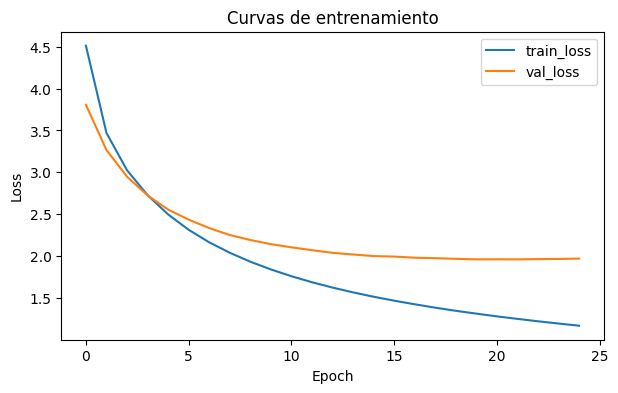

In [67]:
test_epoch_change(128)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | encoder_embedding | Embedding        | 400 K  | train
1 | encoder_lstm      | LSTM             | 9.8 K  | train
2 | decoder_embedding | Embedding        | 240 K  | train
3 | decoder_lstm      | LSTM             | 7.4 K  | train
4 | fc                | Linear           | 248 K  | train
5 | loss_fn           | CrossEntropyLoss | 0      | train
---------------------------------------------------------------
505 K     Trainable params
400 K     Non-trainable params
905 K     Total params
3.621     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/tmp/ipykernel_19525/1396719371.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.encoder_inputs[idx], dtype=torch.long),
/tmp/ipykernel_19525/1396719371.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.decoder_inputs[idx], dtype=torch.long),
/tmp/ipykernel_19525/1396719371.py:16: Use

Epoch 29: 100%|██████████| 744/744 [00:08<00:00, 88.31it/s, v_num=15, val_loss=2.810, train_loss=2.630] 

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 744/744 [00:08<00:00, 87.96it/s, v_num=15, val_loss=2.810, train_loss=2.630]


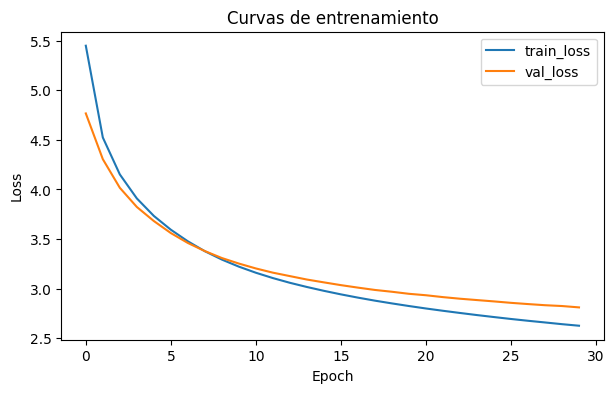

In [68]:
test_epoch_change(30)

Al analizar estos resultados, observamos lo que se mencionaba anteriormente: al aumentar el numero de capas ocultas en los LSTM, tendremos mejor desempeño, aunque incrementará el numero total de parámetros, como también incrementará el tiempo de entrenamiento